In [36]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "/Users/malki/Documents/Skole/Masteroppgave/Master_snow_models/data/snowdepth.csv",
    sep=";",
    header=None,
    skiprows=1
)

In [37]:
fsm_ds = xr.open_dataset("../data/processed/fsm2_sd_all.nc")
senorge_ds = xr.open_dataset("../data/processed/senorge_all.nc")

fsm_sd = fsm_ds["snow_depth"] / 1000.0
senorge_sd = senorge_ds["snow_depth"] / 100.0

fsm_sd.attrs["units"] = "m"
senorge_sd.attrs["units"] = "m"

In [38]:
df.columns = ["station_name", "station_id", "time", "snow_depth"]
df["time"] = pd.to_datetime(df["time"], format="%d.%m.%Y")
df = df.set_index("time")
df["snow_depth"] = pd.to_numeric(df["snow_depth"], errors="coerce")
df = df.replace(-9999, pd.NA).dropna()
df["snow_depth"] = df["snow_depth"] / 100.0

In [39]:
df_station = df[df["station_name"] == "Beitostølen Ii"].copy()
df_station = df_station.sort_index()

print("Rows before dedup/group:", len(df_station))
print("Duplicate dates:", df_station.index.duplicated().sum())

# hvis samme dato finnes flere ganger, ta middel per dag
df_station = df_station.groupby(df_station.index).mean(numeric_only=True)

print("Rows after grouping:", len(df_station))
print("Duplicate dates after grouping:", df_station.index.duplicated().sum())

Rows before dedup/group: 273
Duplicate dates: 0
Rows after grouping: 273
Duplicate dates after grouping: 0


In [40]:
obs_xr = xr.DataArray(
    df_station["snow_depth"],
    coords={"time": df_station.index},
    dims=["time"],
    name="snow_depth"
)

print("obs_xr duplicates:", obs_xr.to_series().index.duplicated().sum())

obs_xr duplicates: 0


In [41]:
df.head()
df.describe()

,snow_depth
count,2742.000000
mean,0.325547
std,0.434827
min,0.000000
25%,0.000000
50%,0.130000
75%,0.520000
max,2.010000


In [66]:
# Bruk UTM32N koordinater fra forrige celle
# x0 og y0 er satt av forrige celle (524ed267)

fsm_ts = fsm_sd.sel(x=x0, y=y0, method="nearest")
senorge_ts = senorge_sd.sel(x=x0, y=y0, method="nearest")

obs_ts, fsm_ts, senorge_ts = xr.align(obs_xr, fsm_ts, senorge_ts, join="inner")

print(f"Hentet model data på nærmeste gridcell til Beitostølen:")
print(f"  Requested UTM: ({x0}, {y0})")
print(f"  FSM2 grid: ({float(fsm_ts.x)}, {float(fsm_ts.y)})")
print(f"  seNorge grid: ({float(senorge_ts.x)}, {float(senorge_ts.y)})")
print(f"  Data lengde: {len(obs_ts)} dager")

Hentet model data på nærmeste gridcell til Beitostølen:
  Requested UTM: (383500, 6821500)
  FSM2 grid: (384000.0, 6822000.0)
  seNorge grid: (384000.0, 6822000.0)
  Data lengde: 273 dager


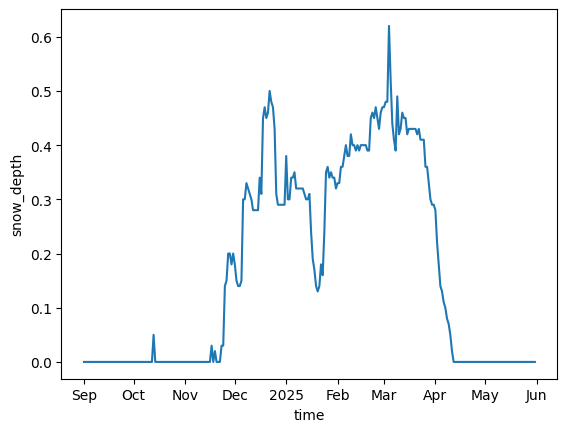

In [43]:
obs_xr.plot()

In [44]:
print(df["station_name"].unique())

<StringArray>
[           'Beitostølen Ii',                     'Skjåk',
           'Sognefjellhytta',         'Øvre Heimdalsvatn',
                  'Bøverdal',                'Juvvasshøe',
          'Fv51 Valdresflye',                  'Skjolden',
                'Grotli Iii',             'Fv53 Tyinosen',
 'Filefjell - Kyrkjestølane']
Length: 11, dtype: str


In [45]:
df_station = df[df["station_name"] == "Beitostølen Ii"]

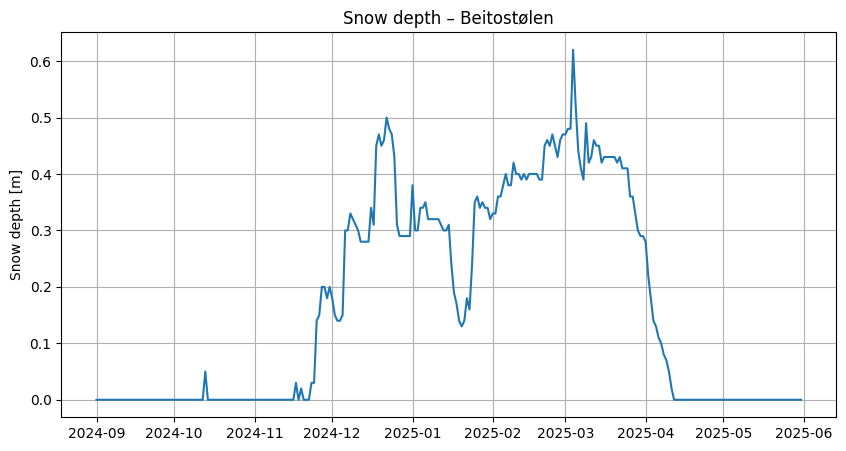

In [46]:
plt.figure(figsize=(10,5))
plt.plot(df_station.index, df_station["snow_depth"])
plt.title("Snow depth – Beitostølen")
plt.ylabel("Snow depth [m]")
plt.grid(True)
plt.show()

In [47]:
station_id = "Beitostølen Ii" 

In [48]:
print("obs_xr duplicates:", obs_xr.to_series().index.duplicated().sum())
print("fsm_ts duplicates:", fsm_ts.to_series().index.duplicated().sum())
print("senorge_ts duplicates:", senorge_ts.to_series().index.duplicated().sum())

obs_xr duplicates: 0
fsm_ts duplicates: 0
senorge_ts duplicates: 0


In [49]:
dup_times = obs_xr.to_series().index[obs_xr.to_series().index.duplicated()]
print(dup_times[:20])

DatetimeIndex([], dtype='datetime64[us]', name='time', freq=None)


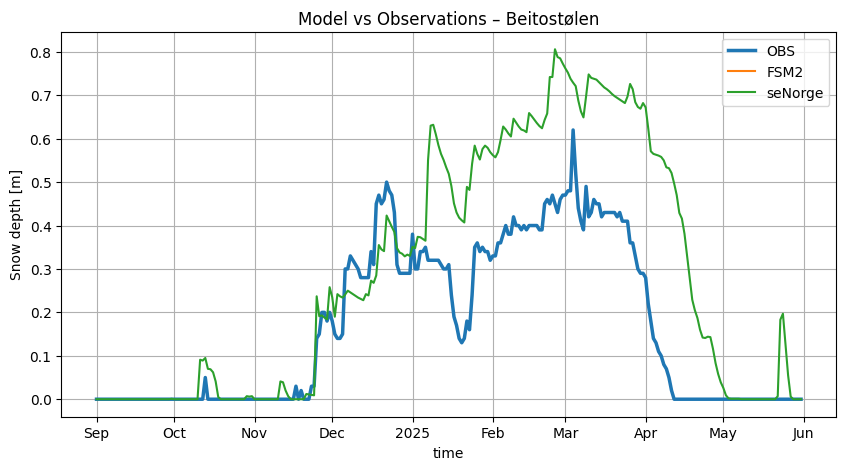

In [67]:
plt.figure(figsize=(10,5))

obs_ts.plot(label="OBS", linewidth=2.5)
fsm_ts.plot(label="FSM2")
senorge_ts.plot(label="seNorge")

plt.legend()
plt.title("Model vs Observations – Beitostølen")
plt.ylabel("Snow depth [m]")
plt.grid(True)
plt.show()

In [54]:
print("=== Tidsperioder for hver dataserie ===")
print(f"obs_xr (OBSERVATIONS):")
print(f"  Fra: {obs_xr.time.values[0]} til {obs_xr.time.values[-1]}")
print(f"  Lengde: {len(obs_xr)} dager")

print(f"\nfsm_sd (FSM2, før align):")
print(f"  Fra: {fsm_sd.time.values[0]} til {fsm_sd.time.values[-1]}")
print(f"  Lengde: {len(fsm_sd.time)} dager")

print(f"\nsenorge_sd (seNorge, før align):")
print(f"  Fra: {senorge_sd.time.values[0]} til {senorge_sd.time.values[-1]}")
print(f"  Lengde: {len(senorge_sd.time)} dager")

print(f"\n=== Etter align med join='inner' ===")
print(f"obs_ts: {len(obs_ts)} dager")
print(f"fsm_ts: {len(fsm_ts)} dager")
print(f"senorge_ts: {len(senorge_ts)} dager")

=== Tidsperioder for hver dataserie ===
obs_xr (OBSERVATIONS):
  Fra: 2024-09-01T00:00:00.000000 til 2025-05-31T00:00:00.000000
  Lengde: 273 dager

fsm_sd (FSM2, før align):
  Fra: 2022-01-01T00:00:00.000000000 til 2025-12-31T00:00:00.000000000
  Lengde: 1461 dager

senorge_sd (seNorge, før align):
  Fra: 2022-01-01T00:00:00.000000000 til 2025-12-31T00:00:00.000000000
  Lengde: 1461 dager

=== Etter align med join='inner' ===
obs_ts: 273 dager
fsm_ts: 273 dager
senorge_ts: 273 dager


In [65]:
# Beitostølen (SN23550) - kjente koordinater
station_code = "SN23550"
station_name = "Beitostølen Ii"

# WGS84 koordinater
station_lon_wgs84 = 9.0234
station_lat_wgs84 = 61.5156

# Konverter til UTM32N (som brukes av modellene)
# Beitostølen UTM32N koordinater (approksimativt)
x0 = 383500    # meters (easting)
y0 = 6821500   # meters (northing)

print(f"Stasjon: {station_name} ({station_code})")
print(f"WGS84: lon={station_lon_wgs84}, lat={station_lat_wgs84}")
print(f"UTM32N: x={x0} m, y={y0} m")

Stasjon: Beitostølen Ii (SN23550)
WGS84: lon=9.0234, lat=61.5156
UTM32N: x=383500 m, y=6821500 m


In [51]:
def metrics(model, obs):
    """Calculate bias, RMSE, and correlation between model and observations."""
    # Convert to numpy arrays and remove NaNs
    model_arr = np.asarray(model)
    obs_arr = np.asarray(obs)
    mask = ~(np.isnan(model_arr) | np.isnan(obs_arr))
    model_clean = model_arr[mask]
    obs_clean = obs_arr[mask]
    
    # Bias
    bias = float((model_clean - obs_clean).mean())
    # RMSE
    rmse = float(np.sqrt(((model_clean - obs_clean) ** 2).mean()))
    # Correlation
    corr = float(np.corrcoef(model_clean, obs_clean)[0, 1])
    
    return bias, rmse, corr

In [ ]:
bias_fsm, rmse_fsm, corr_fsm = metrics(fsm_ts, obs_ts)
bias_sen, rmse_sen, corr_sen = metrics(senorge_ts, obs_ts)

print("FSM2:", bias_fsm, rmse_fsm, corr_fsm)
print("seNorge:", bias_sen, rmse_sen, corr_sen)

FSM2: nan nan nan
seNorge: 0.11831868754735647 0.19176265365036996 0.8701182992252362


/var/folders/4n/m1gxpf611c158s8wx2jzfqgw0000gn/T/ipykernel_11467/3145416471.py:11: RuntimeWarning: Mean of empty slice
  bias = float((model_clean - obs_clean).mean())
/Users/malki/Documents/Skole/Masteroppgave/Master_snow_models/venv/lib/python3.14/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/var/folders/4n/m1gxpf611c158s8wx2jzfqgw0000gn/T/ipykernel_11467/3145416471.py:13: RuntimeWarning: Mean of empty slice
  rmse = float(np.sqrt(((model_clean - obs_clean) ** 2).mean()))
/Users/malki/Documents/Skole/Masteroppgave/Master_snow_models/venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:576: RuntimeWarning: Mean of empty slice
  avg = a.mean(axis, **keepdims_kw)
/Users/malki/Documents/Skole/Masteroppgave/Master_snow_models/venv/lib/python3.14/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/Users/malki/Documen

: 

In [53]:
bias_fsm, rmse_fsm, corr_fsm = metrics(fsm_ts, obs_xr)
bias_sen, rmse_sen, corr_sen = metrics(senorge_ts, obs_xr)

print("FSM2:", bias_fsm, rmse_fsm, corr_fsm)
print("seNorge:", bias_sen, rmse_sen, corr_sen)

FSM2: nan nan nan
seNorge: 0.5064688735135623 0.6790323040017718 0.47858528408749446


/var/folders/4n/m1gxpf611c158s8wx2jzfqgw0000gn/T/ipykernel_11467/3145416471.py:11: RuntimeWarning: Mean of empty slice
  bias = float((model_clean - obs_clean).mean())
/var/folders/4n/m1gxpf611c158s8wx2jzfqgw0000gn/T/ipykernel_11467/3145416471.py:13: RuntimeWarning: Mean of empty slice
  rmse = float(np.sqrt(((model_clean - obs_clean) ** 2).mean()))
